In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, levene

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import warnings; warnings.filterwarnings('ignore')

from imblearn.over_sampling  import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine        import SMOTETomek
from imblearn.ensemble       import BalancedRandomForestClassifier
import xgboost as xgb

from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc
)

In [4]:
# 데이터 concat

# df1 = pd.read_csv('C:/Users/VScode/features_train.csv', encoding='utf-8')
# df2 = pd.read_csv('C:/Users/VScode/labels_train.csv', encoding='utf-8')

# result_data = pd.concat([df1,df2], axis=1)
# result_data.to_csv('semiconductor.csv', index=False)

In [5]:
from google.colab import drive
drive.mount('/content/drive') # 구글 드라이브 연결

result_data = '/content/drive/MyDrive/semiconductor.csv'

df = pd.read_csv(result_data)
df.head(3)

# df = pd.read_csv('/content/semiconductor.csv', encoding='utf-8')
# df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-0.381981,-0.917519,2.905965,NaN,14.642069,NaN,2.249968,NaN,NaN,1
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,NaN,-4.937284,0.089265,-4.937284,12.361204,NaN,3.381750,5.827666,-0.056206,1
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,5.685728,NaN,0.871249,-0.955908,1.587669,1.665659,-0.052572,-0.597566,-2.745544,0


In [6]:
df.duplicated().sum()

np.int64(0)

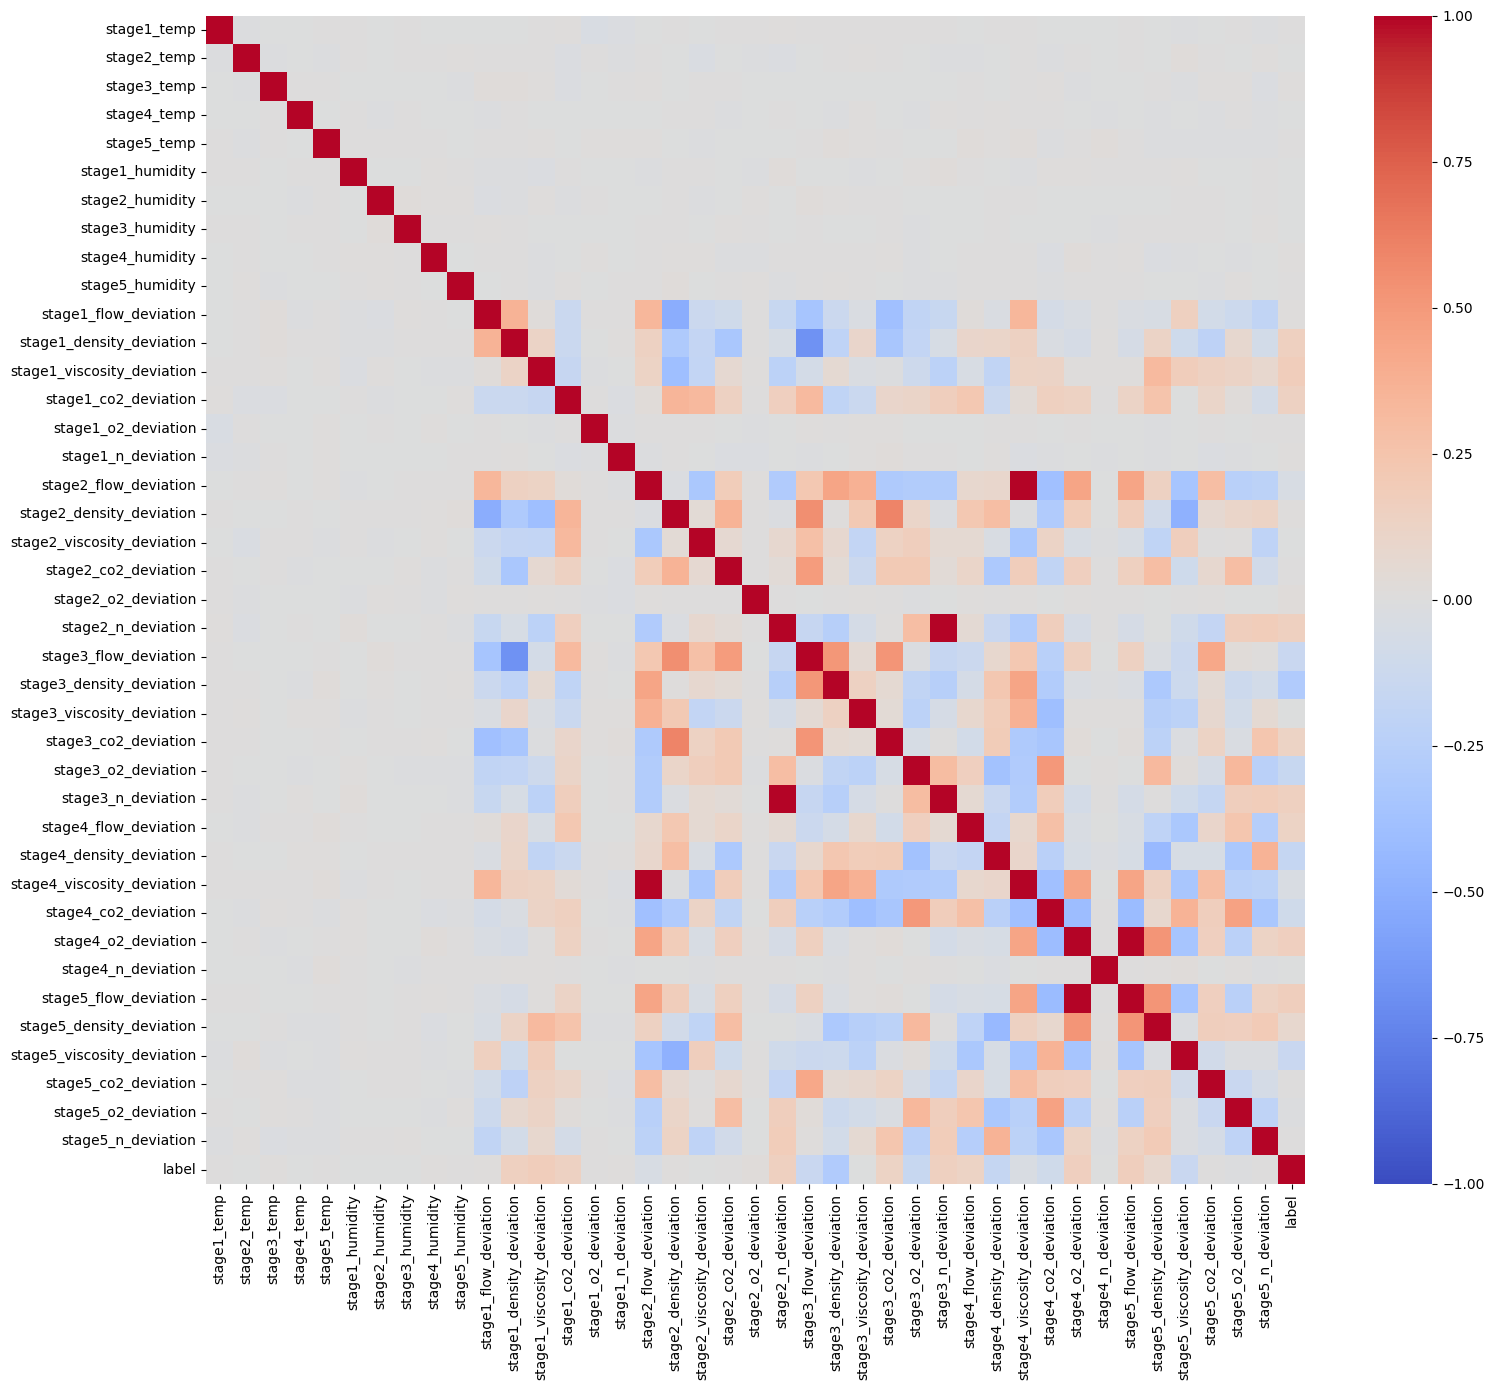

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0,vmin=-1, vmax=1,annot=False)
plt.tight_layout()
plt.show()

In [8]:
# 상관계수가 1인 컬럼 제거
df = df.drop(columns=['stage2_flow_deviation', 'stage5_flow_deviation', 'stage2_n_deviation'])
df.head(3)

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_viscosity_deviation,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,3.897850,-0.381981,-0.917519,2.905965,14.642069,NaN,2.249968,NaN,NaN,1
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,-0.336600,NaN,-4.937284,0.089265,12.361204,NaN,3.381750,5.827666,-0.056206,1
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,5.108084,5.685728,NaN,0.871249,1.587669,1.665659,-0.052572,-0.597566,-2.745544,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16998 entries, 0 to 16997
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   stage1_temp                 16998 non-null  float64
 1   stage2_temp                 16998 non-null  float64
 2   stage3_temp                 16998 non-null  float64
 3   stage4_temp                 16998 non-null  float64
 4   stage5_temp                 16998 non-null  float64
 5   stage1_humidity             16998 non-null  float64
 6   stage2_humidity             16998 non-null  float64
 7   stage3_humidity             16998 non-null  float64
 8   stage4_humidity             16998 non-null  float64
 9   stage5_humidity             16998 non-null  float64
 10  stage1_flow_deviation       11188 non-null  float64
 11  stage1_density_deviation    16073 non-null  float64
 12  stage1_viscosity_deviation  15591 non-null  float64
 13  stage1_co2_deviation        106

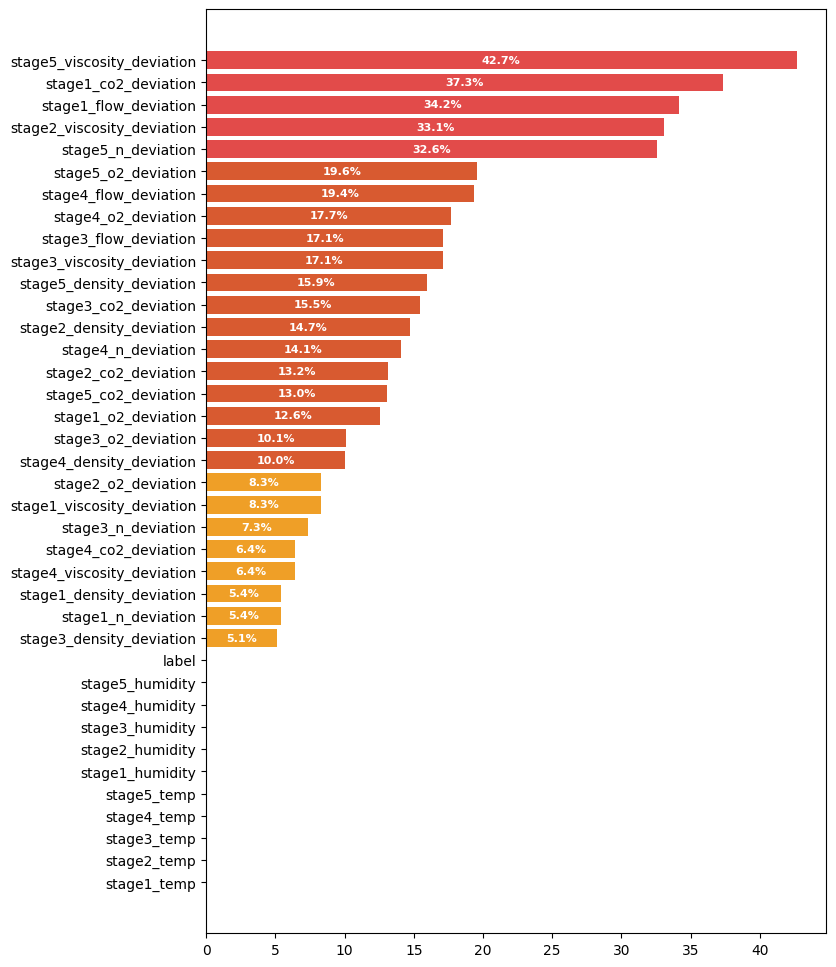

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 결측률
missing_pct = df.isnull().mean() * 100
present_pct = 100 - missing_pct

# 결측률 기준 그룹 색상 지정
def get_color(pct):
    if pct == 0:     return '#639922'
    elif pct <= 10:  return '#EF9F27'
    elif pct <= 20:  return '#D85A30'
    else:            return '#E24B4A'

missing_colors = [get_color(p) for p in missing_pct]

# 결측률 기준 내림차순
sorted_idx = missing_pct.sort_values(ascending=True).index
sorted_missing = missing_pct[sorted_idx]
sorted_present = present_pct[sorted_idx]
sorted_colors  = [get_color(p) for p in sorted_missing]

# 차트
fig, ax = plt.subplots(figsize=(8, 12))

plt.barh(sorted_idx, sorted_missing, color=sorted_colors)

# 결측치 % 라벨
for i, (pct, prs) in enumerate(zip(sorted_missing, sorted_present)):
    if pct > 0:
        ax.text(pct / 2, i, f'{pct:.1f}%',
                va='center', ha='center',
                fontsize=8, color='white', fontweight='bold')

plt.show()

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# X, y 분리
X = df.drop(columns='label')
y = df['label']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 결측률 계산
high_threshold = 20
mid_threshold = 20

missing_rate = X_train.isnull().mean() * 100

missing_rate_df = pd.DataFrame({
    'column': missing_rate.index,
    'missing_rate': missing_rate.values
})

# 컬럼 분류
mice_cols = missing_rate_df[
    missing_rate_df['missing_rate'] >= high_threshold
]['column'].tolist()

knn_cols = missing_rate_df[
    (missing_rate_df['missing_rate'] >= mid_threshold) &
    (missing_rate_df['missing_rate'] < high_threshold)
]['column'].tolist()

mean_cols = missing_rate_df[
    (missing_rate_df['missing_rate'] > 0) &
    (missing_rate_df['missing_rate'] < mid_threshold)
]['column'].tolist()

print("MICE:", mice_cols)
print("KNN:", knn_cols)
print("MEAN:", mean_cols)

# MICE
if len(mice_cols) > 0:
    mice_imputer = IterativeImputer(random_state=42, max_iter=10)

    # train fit + transform
    X_train_imp = mice_imputer.fit_transform(X_train)
    X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)

    # test는 transform만
    X_test_imp = mice_imputer.transform(X_test)
    X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)

    X_train[mice_cols] = X_train_imp[mice_cols]
    X_test[mice_cols] = X_test_imp[mice_cols]

# KNN
if len(knn_cols) > 0:
    knn_imputer = KNNImputer(n_neighbors=5)

    X_train_imp = knn_imputer.fit_transform(X_train)
    X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)

    X_test_imp = knn_imputer.transform(X_test)
    X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)

    X_train[knn_cols] = X_train_imp[knn_cols]
    X_test[knn_cols] = X_test_imp[knn_cols]

# 평균
for col in mean_cols:
    mean_val = X_train[col].mean()   # 반드시 train 기준!
    X_train[col] = X_train[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

# 결측치 확인
print("Train 결측:", X_train.isnull().sum().sum())
print("Test 결측:", X_test.isnull().sum().sum())

MICE: ['stage1_flow_deviation', 'stage1_co2_deviation', 'stage2_viscosity_deviation', 'stage5_viscosity_deviation', 'stage5_n_deviation']
KNN: []
MEAN: ['stage1_density_deviation', 'stage1_viscosity_deviation', 'stage1_o2_deviation', 'stage1_n_deviation', 'stage2_density_deviation', 'stage2_co2_deviation', 'stage2_o2_deviation', 'stage3_flow_deviation', 'stage3_density_deviation', 'stage3_viscosity_deviation', 'stage3_co2_deviation', 'stage3_o2_deviation', 'stage3_n_deviation', 'stage4_flow_deviation', 'stage4_density_deviation', 'stage4_viscosity_deviation', 'stage4_co2_deviation', 'stage4_o2_deviation', 'stage4_n_deviation', 'stage5_density_deviation', 'stage5_co2_deviation', 'stage5_o2_deviation']
Train 결측: 0
Test 결측: 0


In [12]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_const = sm.add_constant(X_train)

# VIF 계산
vif_data = pd.DataFrame()
vif_data['feature'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data.head)

<bound method NDFrame.head of                        feature          VIF
0                        const  5541.524573
29  stage4_viscosity_deviation     8.386706
30        stage4_co2_deviation     6.459011
17    stage2_density_deviation     5.359057
21       stage3_flow_deviation     4.696782
33    stage5_density_deviation     4.375296
22    stage3_density_deviation     3.554101
37          stage5_n_deviation     3.326932
24        stage3_co2_deviation     2.995939
14        stage1_co2_deviation     2.961657
28    stage4_density_deviation     2.854069
11       stage1_flow_deviation     2.655202
34  stage5_viscosity_deviation     2.646944
19        stage2_co2_deviation     2.589011
12    stage1_density_deviation     2.581858
18  stage2_viscosity_deviation     2.496671
25         stage3_o2_deviation     2.461858
31         stage4_o2_deviation     2.423116
35        stage5_co2_deviation     2.301632
36         stage5_o2_deviation     2.128786
27       stage4_flow_deviation     1.994847
23



---



---


# 추론 통계

In [13]:
# t-test
print("=== Independent t-test (train 기준) ===")

ttest_results = []
for col in X_train.columns:
    group0 = X_train[col][y_train == 0].dropna()
    group1 = X_train[col][y_train == 1].dropna()
    stat, p = ttest_ind(group0, group1)
    ttest_results.append({'feature': col, 'p_ttest': p, 'sig_ttest': p < 0.05})
    print(f"{col}: p={p:.4f} {'-> 유의' if p < 0.05 else ''}")

ttest_df = pd.DataFrame(ttest_results)

# Mann-Whitney
print("\n=== Mann-Whitney U test (train 기준) ===")

mw_results = []
for col in X_train.columns:
    group0 = X_train[col][y_train == 0].dropna()
    group1 = X_train[col][y_train == 1].dropna()
    if len(group0) == 0 or len(group1) == 0:
        continue
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    mw_results.append({'feature': col, 'p_mw': p, 'sig_mw': p < 0.05})
    print(f"{col}: p={p:.4f} {'-> 유의' if p < 0.05 else ''}")

mw_df = pd.DataFrame(mw_results)

# 두 검정 비교표
compare_df = ttest_df.merge(mw_df, on='feature')
compare_df['status'] = compare_df.apply(
    lambda r: ' 일치' if r['sig_ttest'] == r['sig_mw']
              else (' MW만 유의 (채택)' if r['sig_mw'] else ' t-test만 유의'),
    axis=1
)
print("\n=== 두 검정 비교 ===")
print(compare_df[['feature','p_ttest','p_mw','status']].to_string(index=False))

# 최종 feature 확정 (Mann-Whitney 기준)
significant_cols = mw_df[mw_df['sig_mw']]['feature'].tolist()
print(f"\n총 {X_train.shape[1]}개 → 유의 feature: {len(significant_cols)}개")

X_train_final = X_train[significant_cols]
X_test_final  = X_test[significant_cols]
print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final : {X_test_final.shape}")

=== Independent t-test (train 기준) ===
stage1_temp: p=0.7808 
stage2_temp: p=0.7054 
stage3_temp: p=0.0571 
stage4_temp: p=0.2503 
stage5_temp: p=0.9610 
stage1_humidity: p=0.2911 
stage2_humidity: p=0.3239 
stage3_humidity: p=0.8979 
stage4_humidity: p=0.5494 
stage5_humidity: p=0.3761 
stage1_flow_deviation: p=0.8870 
stage1_density_deviation: p=0.0000 -> 유의
stage1_viscosity_deviation: p=0.0000 -> 유의
stage1_co2_deviation: p=0.0000 -> 유의
stage1_o2_deviation: p=0.6415 
stage1_n_deviation: p=0.0150 -> 유의
stage2_density_deviation: p=0.8991 
stage2_viscosity_deviation: p=0.6121 
stage2_co2_deviation: p=0.5025 
stage2_o2_deviation: p=0.0111 -> 유의
stage3_flow_deviation: p=0.0000 -> 유의
stage3_density_deviation: p=0.0000 -> 유의
stage3_viscosity_deviation: p=0.3261 
stage3_co2_deviation: p=0.0000 -> 유의
stage3_o2_deviation: p=0.0000 -> 유의
stage3_n_deviation: p=0.0000 -> 유의
stage4_flow_deviation: p=0.0000 -> 유의
stage4_density_deviation: p=0.0000 -> 유의
stage4_viscosity_deviation: p=0.0000 -> 유의
sta

In [14]:
# Mann-Whitney 유의 feature를 final로 바로 사용
final_cols = mw_df[mw_df['sig_mw']]['feature'].tolist()

print(f"최종 feature: {len(final_cols)}개")
print(final_cols)

X_train_final = X_train[final_cols]
X_test_final  = X_test[final_cols]

print(f"\nX_train_final: {X_train_final.shape}")
print(f"X_test_final : {X_test_final.shape}")

최종 feature: 20개
['stage1_density_deviation', 'stage1_viscosity_deviation', 'stage1_co2_deviation', 'stage1_n_deviation', 'stage2_o2_deviation', 'stage3_flow_deviation', 'stage3_density_deviation', 'stage3_viscosity_deviation', 'stage3_co2_deviation', 'stage3_o2_deviation', 'stage3_n_deviation', 'stage4_flow_deviation', 'stage4_density_deviation', 'stage4_viscosity_deviation', 'stage4_co2_deviation', 'stage4_o2_deviation', 'stage5_density_deviation', 'stage5_viscosity_deviation', 'stage5_o2_deviation', 'stage5_n_deviation']

X_train_final: (11898, 20)
X_test_final : (5100, 20)




---



---


# 시각화

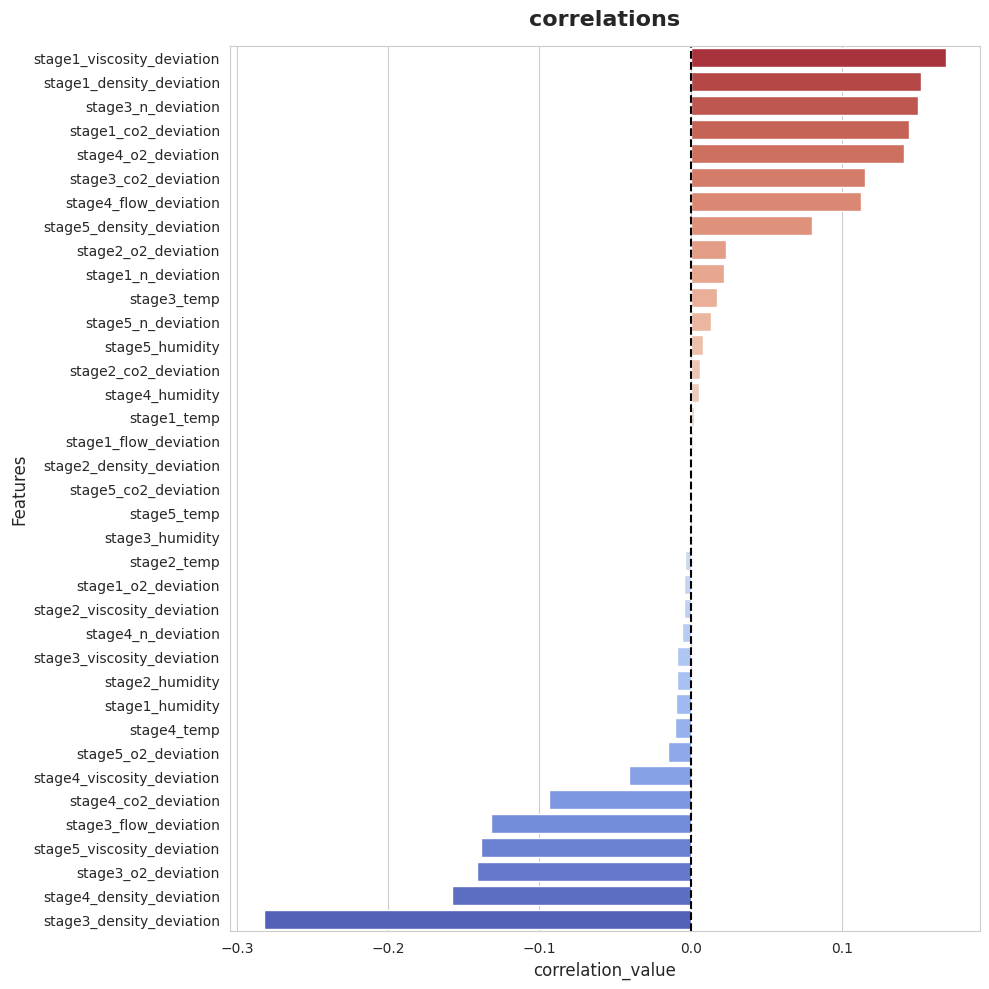

In [15]:
# corr

correlations = X_train.corrwith(y_train).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm_r')

plt.title('correlations', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('correlation_value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5) # 중심 기준선
plt.tight_layout()
plt.show()

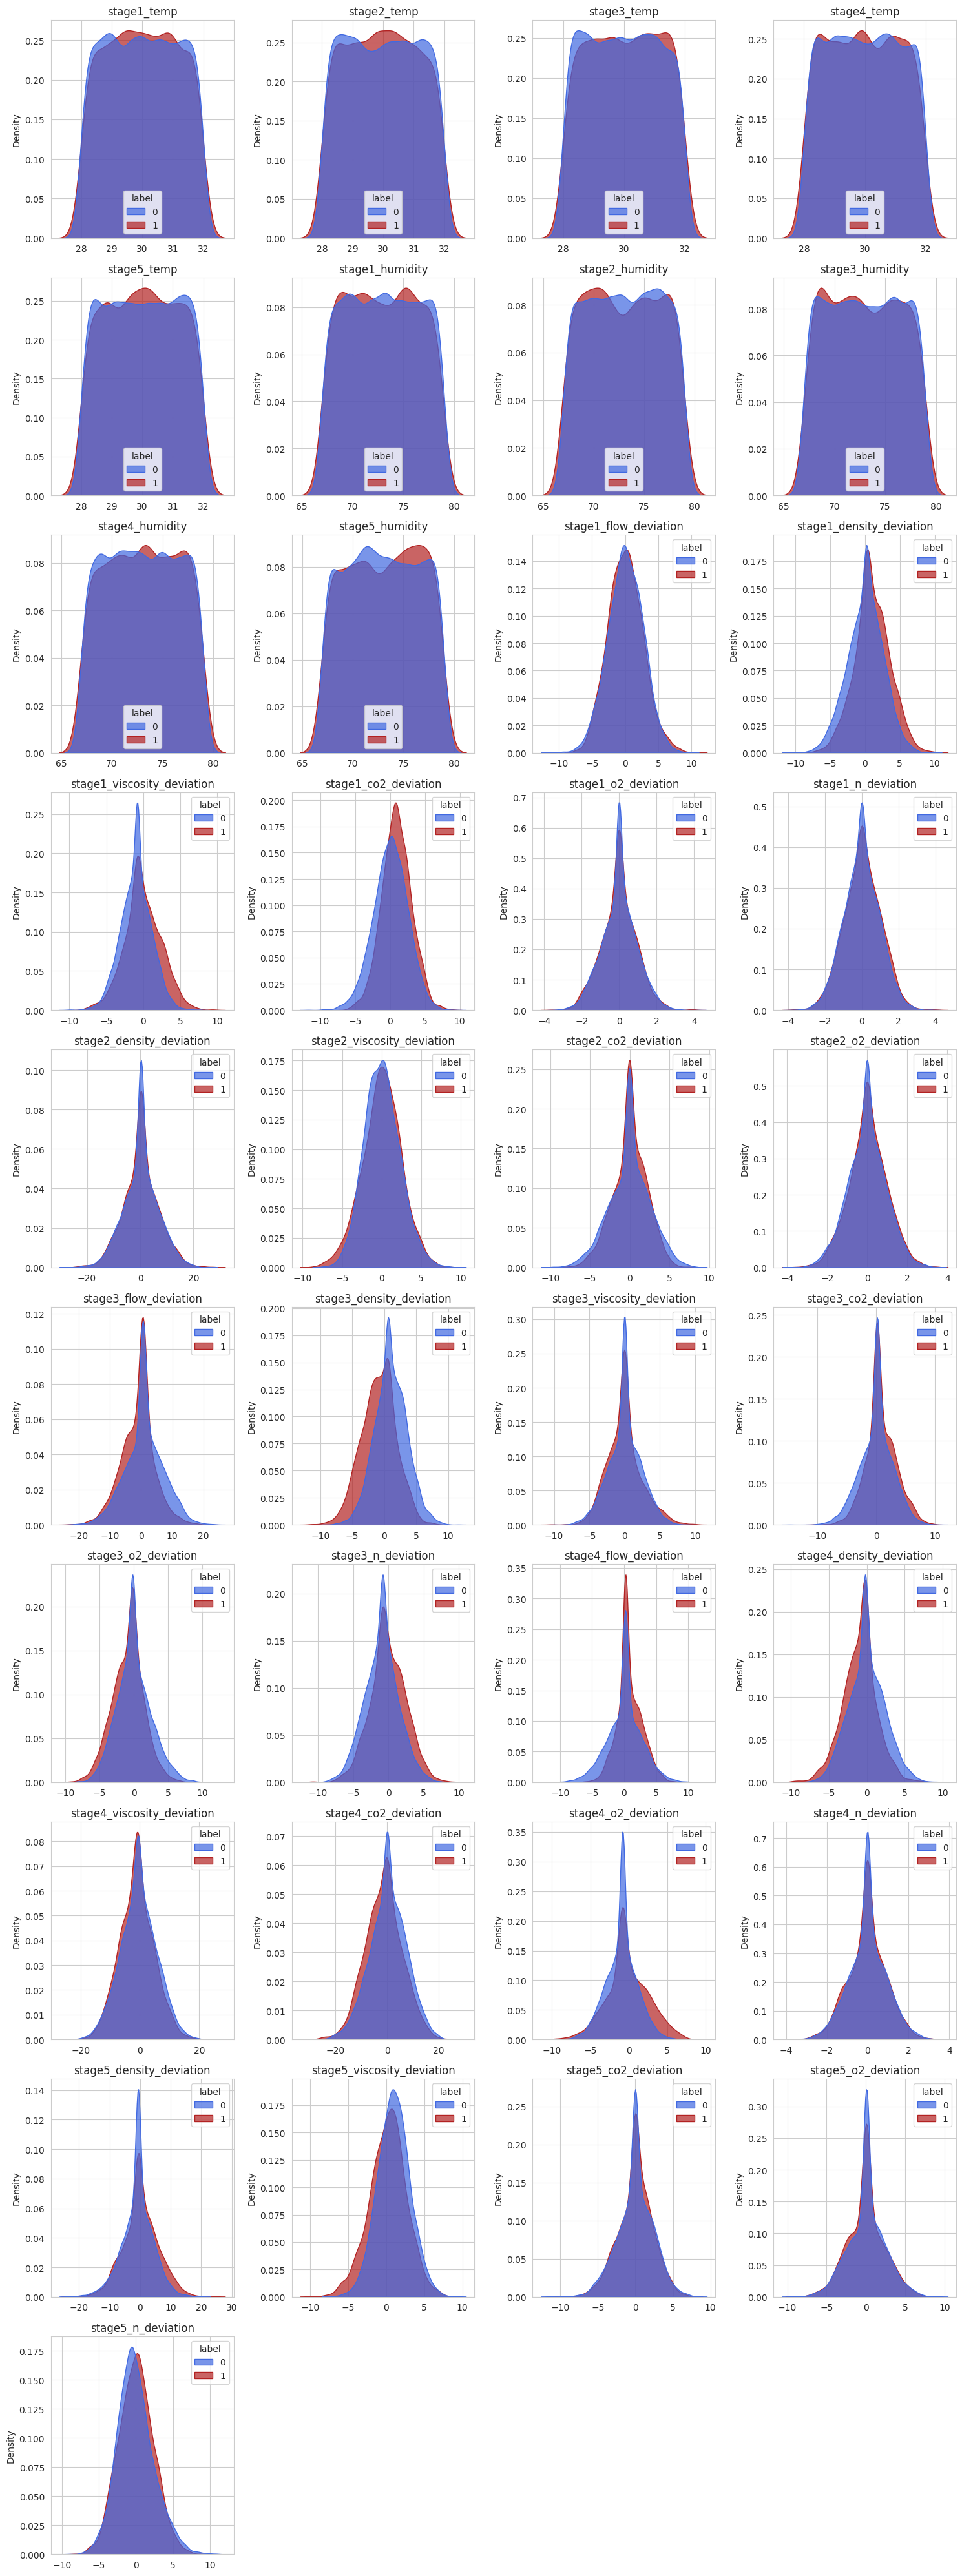

In [16]:
# kde

df_train_all = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

# 독립변수 리스트
features = X_train.columns.tolist()
n_features = len(features)

ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=4, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(
        data=df_train_all,
        x=col,
        hue='label',
        fill=True,
        common_norm=False,
        alpha=0.7,
        ax=axes[i],
        palette={0: 'royalblue', 1: 'firebrick'}
    )

    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

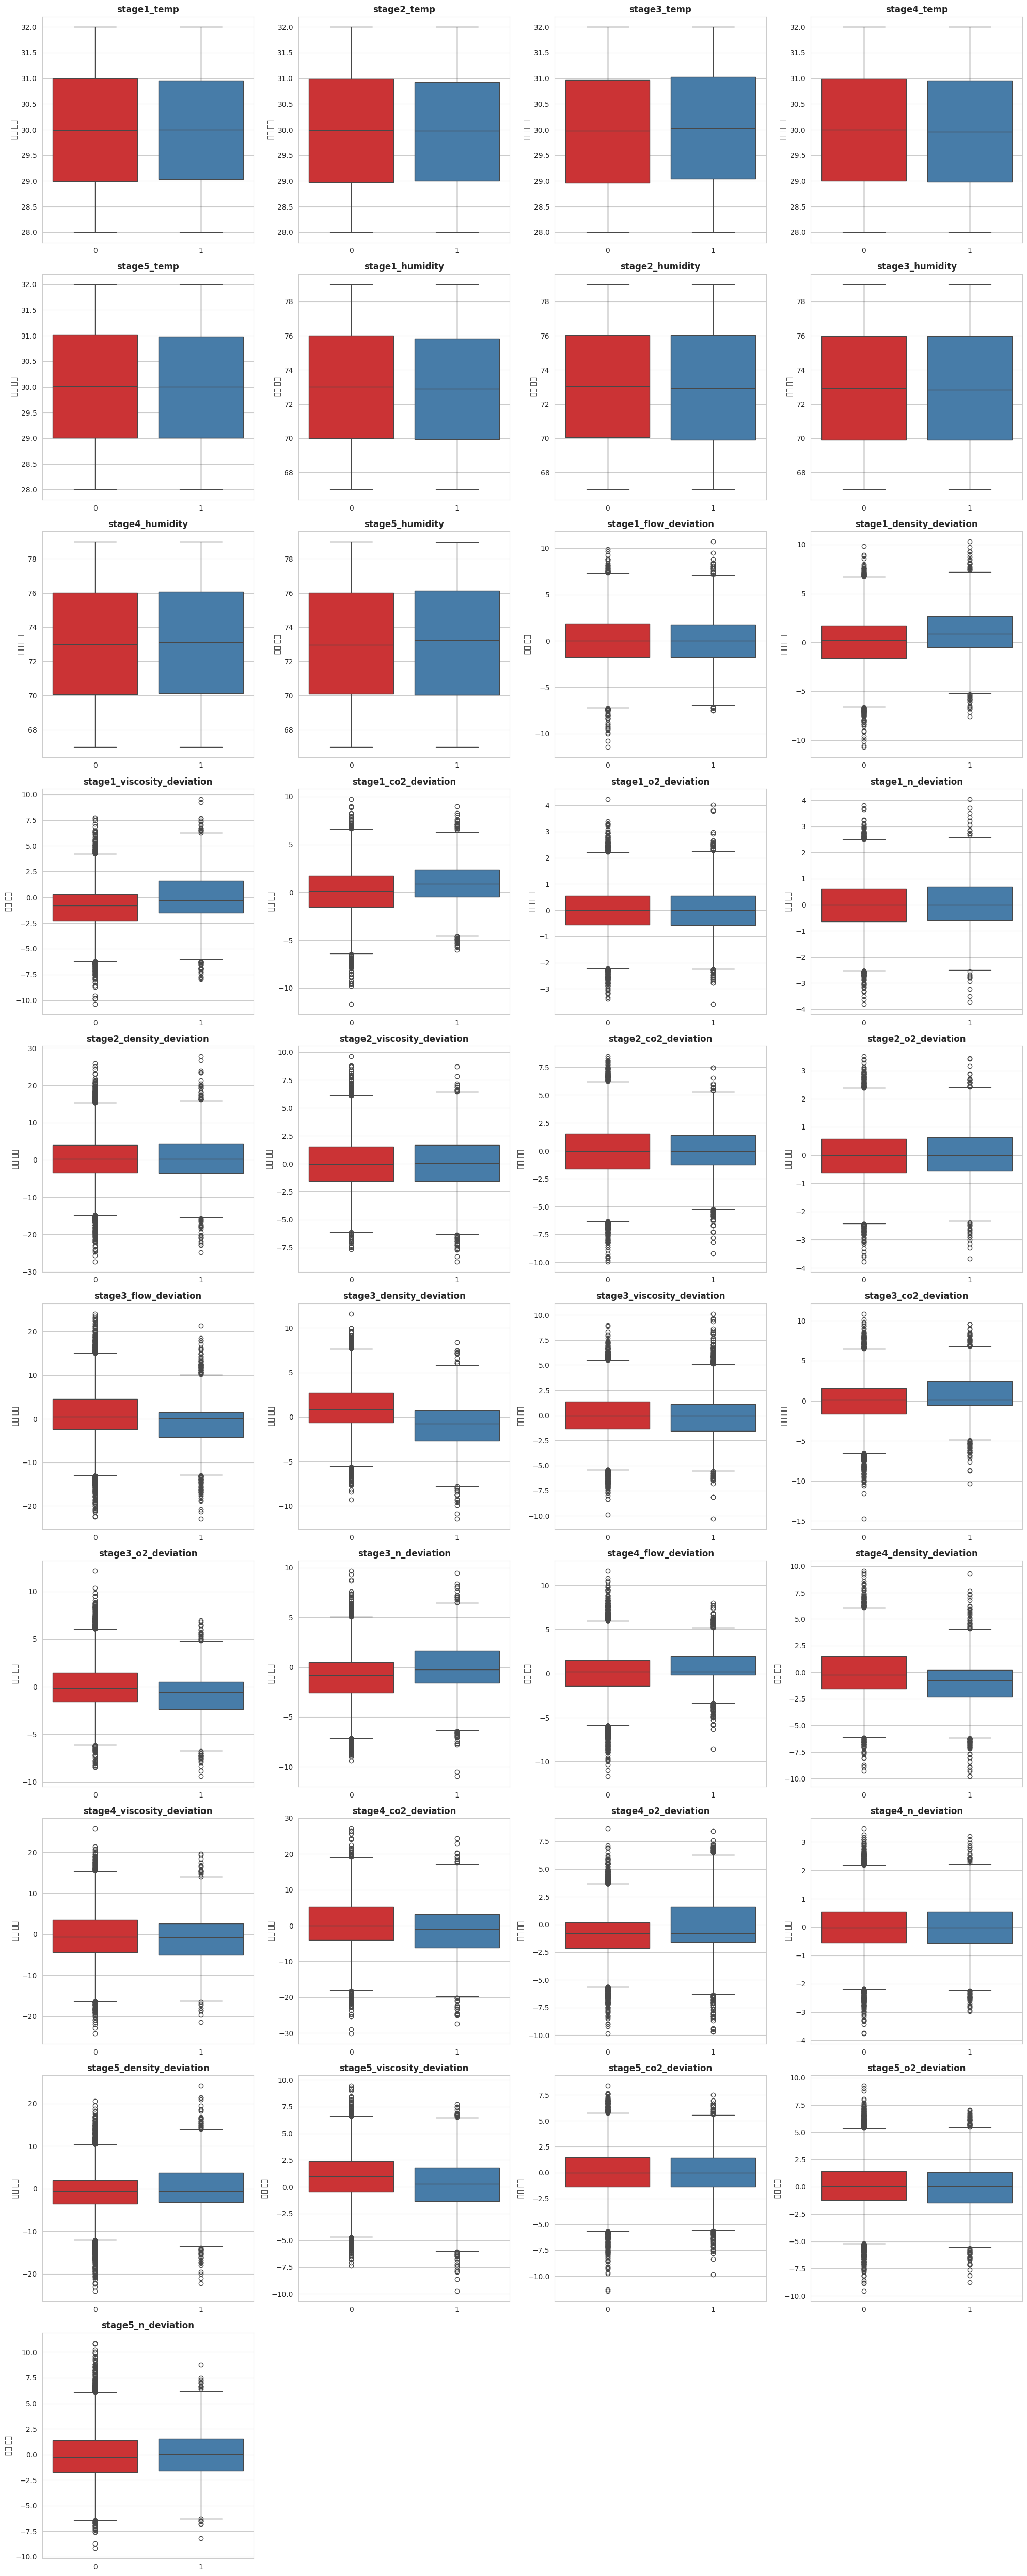

In [17]:
# boxplot

df_train_all = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

features = X_train.columns.tolist()
n_features = len(features)

ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()


for i, col in enumerate(features):
    sns.boxplot(
        data=df_train_all,
        x='label',
        y=col,
        palette='Set1',
        ax=axes[i]
    )

    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('센서 수치')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

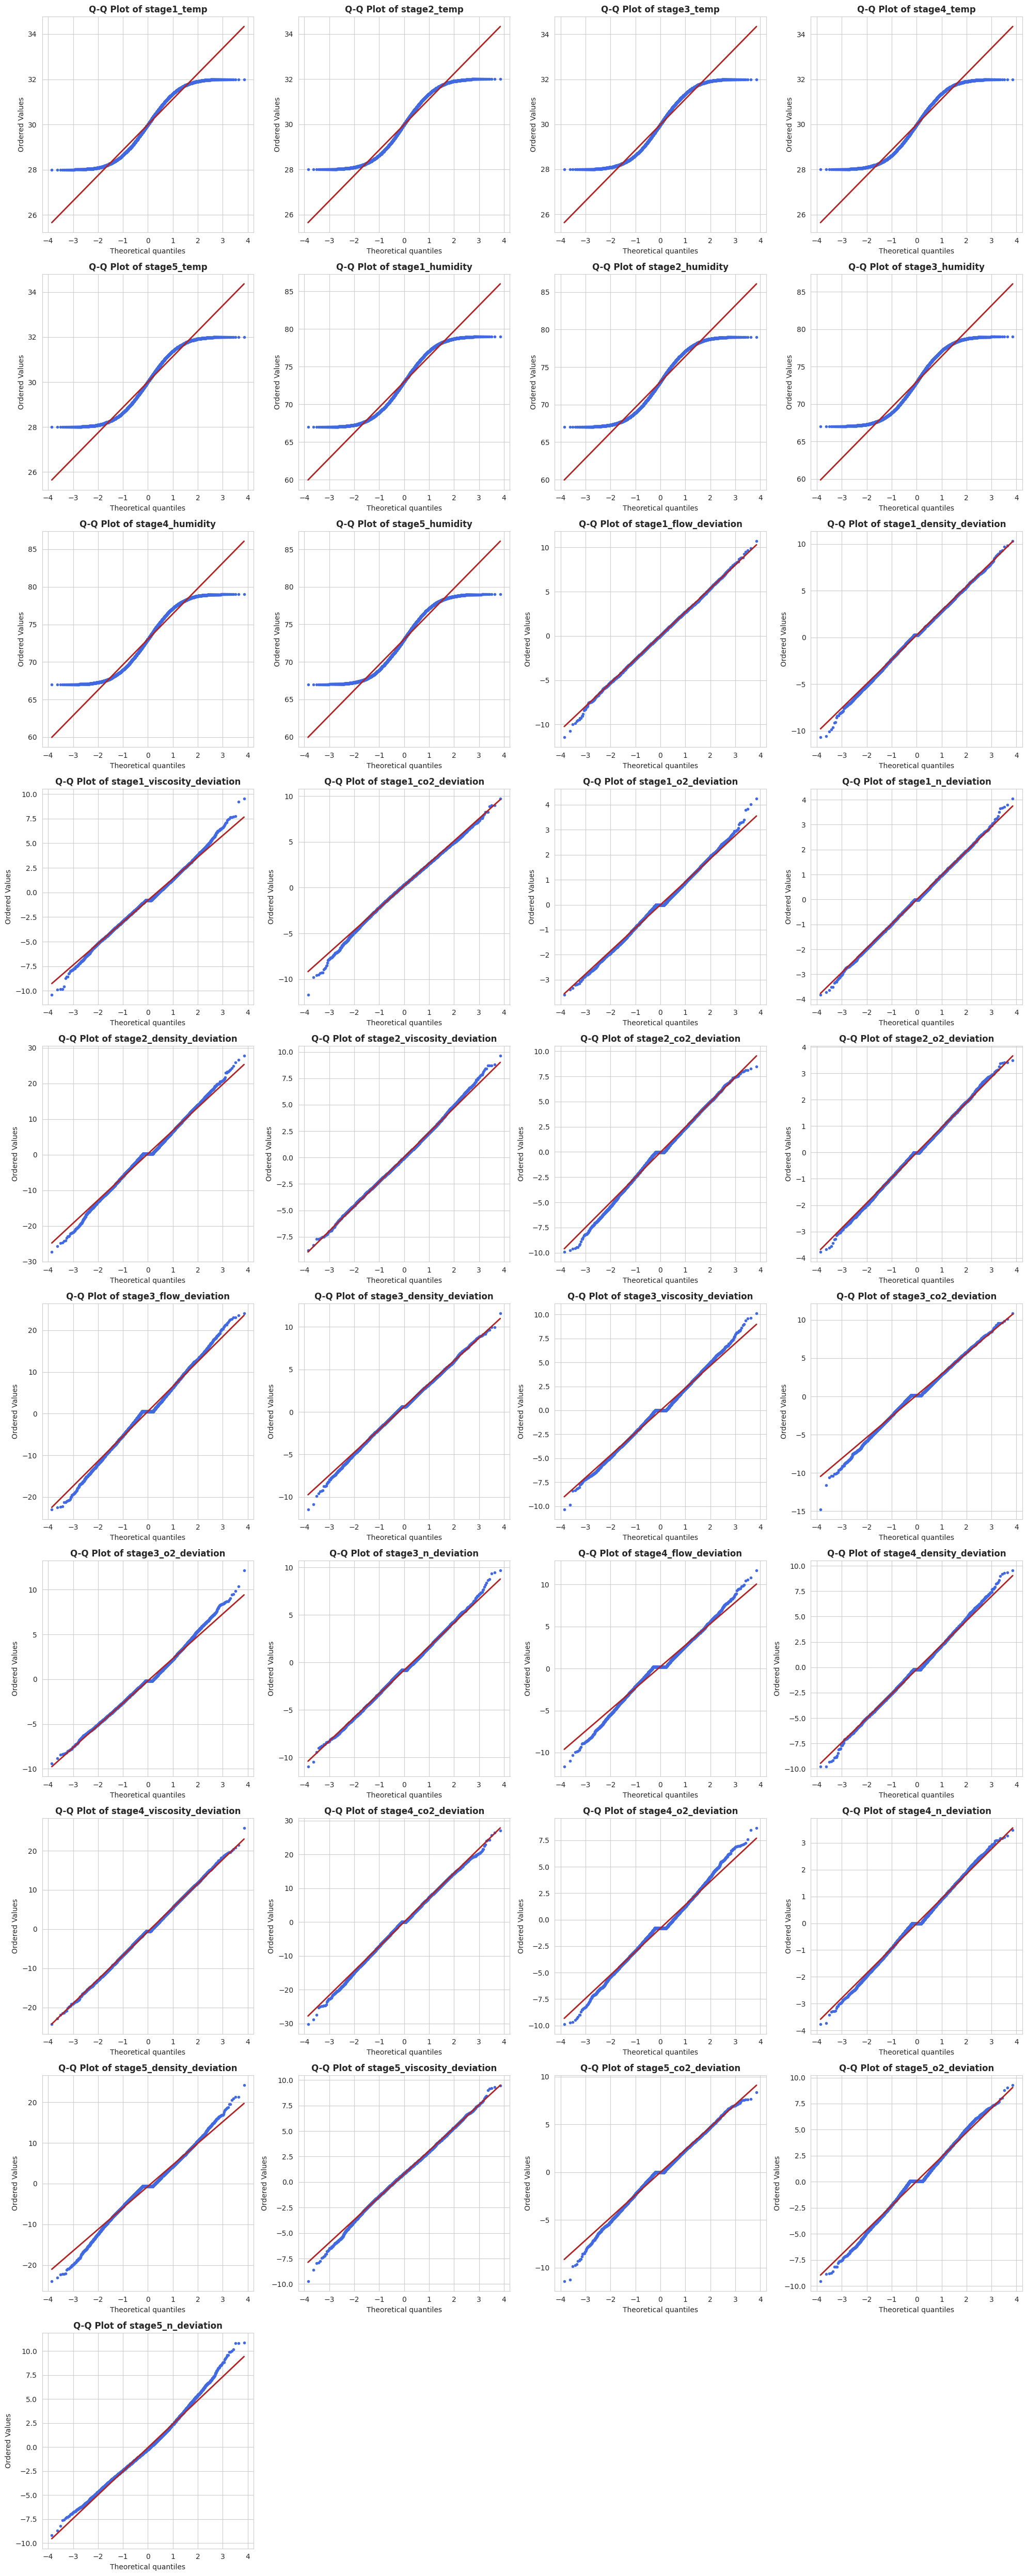

In [18]:
# QQplot

features = X_train.columns.tolist()
n_features = len(features)

ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
sns.set_style("whitegrid")
axes = axes.flatten()


for i, col in enumerate(features):

    stats.probplot(X_train[col], dist="norm", plot=axes[i])

    axes[i].set_title(f'Q-Q Plot of {col}', fontsize=12, fontweight='bold')

    axes[i].get_lines()[0].set_marker('o')
    axes[i].get_lines()[0].set_markerfacecolor('royalblue')
    axes[i].get_lines()[0].set_markeredgecolor('royalblue')
    axes[i].get_lines()[0].set_markersize(3)
    axes[i].get_lines()[1].set_color('firebrick')
    axes[i].get_lines()[1].set_linewidth(2)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

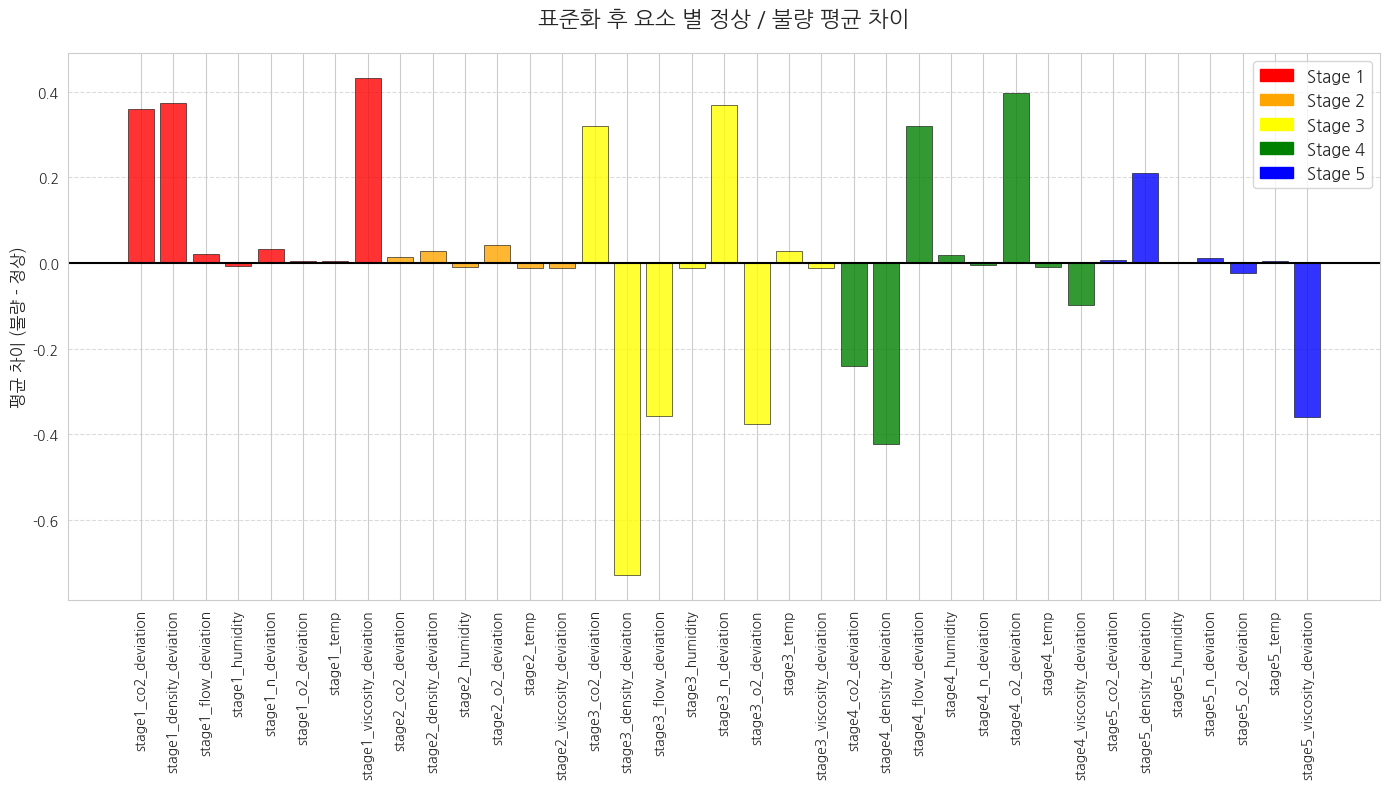

In [19]:
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

feature_cols = [col for col in df.columns if col != 'label']

# 데이터 표준화
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# 평균 차이
mean_normal = df_scaled[df_scaled['label'] == 0][feature_cols].mean()
mean_defect = df_scaled[df_scaled['label'] == 1][feature_cols].mean()
diff = mean_defect - mean_normal

# 시각화를 위한 Stage별 색상 지정
stage_colors = {1: 'red', 2: 'orange', 3: 'yellow', 4: 'green', 5: 'blue'}
colors = []
for feat in feature_cols:
    stage_str = feat.split('_')[0]
    stage_num = int(stage_str.replace('stage', ''))
    colors.append(stage_colors[stage_num])

# 그래프용 데이터프레임 조립
plot_df = pd.DataFrame({
    'Feature': feature_cols,
    'Diff': diff.values,
    'Color': colors
})

# 정렬
plot_df['Stage_Num'] = plot_df['Feature'].apply(lambda x: int(x.split('_')[0].replace('stage', '')))
plot_df = plot_df.sort_values(by=['Stage_Num', 'Feature'])

# 그래프
plt.figure(figsize=(14, 8))
bars = plt.bar(plot_df['Feature'], plot_df['Diff'], color=plot_df['Color'], edgecolor='black', linewidth=0.5, alpha=0.8)

# 중심 기준선
plt.axhline(0, color='black', linewidth=1.5)

plt.ylabel('평균 차이 (불량 - 정상)', fontsize=12)
plt.title('표준화 후 요소 별 정상 / 불량 평균 차이', fontsize=16, pad=20)
plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)

legend_patches = [mpatches.Patch(color=stage_colors[s], label=f'Stage {s}') for s in range(1, 6)]
plt.legend(handles=legend_patches, loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()



---



---


# 머신러닝

## 성능평가 함수

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_eval_results = []
model_train_results = []

def evaluate_model(model_name, y_test, y_pred, y_test_proba, y_train, y_train_pred):

    # ===================== TEST =====================
    test_acc = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)

    # ROC-AUC
    test_roc_auc = roc_auc_score(y_test, y_test_proba)

    print(
        f"{model_name:30s} | TEST  | "
        f"Acc={test_acc:.3f} | P={test_precision:.3f} | "
        f"R={test_recall:.3f} | F1={test_f1:.3f} | ROC-AUC={test_roc_auc:.3f}"
    )

    model_eval_results.append({
        'Model': model_name,
        'Accuracy': test_acc,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1-score': test_f1,
        'ROC-AUC': test_roc_auc
    })

    # ===================== TRAIN =====================
    train_acc = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    print(
        f"{model_name:30s} | TRAIN | "
        f"Acc={train_acc:.3f} | P={train_precision:.3f} | "
        f"R={train_recall:.3f} | F1={train_f1:.3f}"
    )

    model_train_results.append({
        'Model': model_name,
        'Accuracy': train_acc,
        'Precision': train_precision,
        'Recall': train_recall,
        'F1-score': train_f1
    })

## 머신러닝 모델링

In [21]:
#통계추정반영할지 말지에 따라 마크다운 혹은 코드 데이터로 변환하여 사용
X_train = X_train_final
X_test  = X_test_final

In [22]:
# 기본 로지스틱 회귀 모델
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# 성능 평가
print(f"모델 정확도: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n[ 분류 리포트 ]")
print(classification_report(y_test, y_pred, target_names=['정상(0)', '불량(1)']))

evaluate_model("Logistic_Base", y_test, y_pred,y_pred_proba,y_train,lr_model.predict(X_train))

모델 정확도: 86.96%

[ 분류 리포트 ]
              precision    recall  f1-score   support

       정상(0)       0.88      0.97      0.92      4069
       불량(1)       0.79      0.49      0.60      1031

    accuracy                           0.87      5100
   macro avg       0.83      0.73      0.76      5100
weighted avg       0.86      0.87      0.86      5100

Logistic_Base                  | TEST  | Acc=0.870 | P=0.786 | R=0.488 | F1=0.602 | ROC-AUC=0.854
Logistic_Base                  | TRAIN | Acc=0.862 | P=0.759 | R=0.463 | F1=0.575


In [23]:
# 로지스틱(스케일링+class_weight='balanced’)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.preprocessing import StandardScaler

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 생성 (데이터 불균형 대응 포함)
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# 성능 평가
print(f"모델 정확도: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n[ 분류 리포트 ]")
print(classification_report(y_test, y_pred, target_names=['정상(0)', '불량(1)']))

evaluate_model("Logistic_Scaled_Balanced", y_test, y_pred,y_prob,y_train,lr_model.predict(X_train))

모델 정확도: 77.35%

[ 분류 리포트 ]
              precision    recall  f1-score   support

       정상(0)       0.94      0.77      0.84      4069
       불량(1)       0.46      0.80      0.59      1031

    accuracy                           0.77      5100
   macro avg       0.70      0.78      0.72      5100
weighted avg       0.84      0.77      0.79      5100

Logistic_Scaled_Balanced       | TEST  | Acc=0.774 | P=0.465 | R=0.796 | F1=0.587 | ROC-AUC=0.860
Logistic_Scaled_Balanced       | TRAIN | Acc=0.795 | P=0.495 | R=0.720 | F1=0.587


In [24]:
# 로지스틱(스케일링+SMOTE)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 스케일링 (train 기준)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE (train 기준)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
y_train_pred_lr_scaled_smote = lr_model.predict(X_train_smote)

# 성능 평가
print(f"모델 정확도: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n[ 분류 리포트 ]")
print(classification_report(y_test, y_pred, target_names=['정상(0)', '불량(1)']))

evaluate_model("Logistic_Scaled_SMOTE", y_test, y_pred,y_prob,y_train_smote, y_train_pred_lr_scaled_smote)

모델 정확도: 77.45%

[ 분류 리포트 ]
              precision    recall  f1-score   support

       정상(0)       0.93      0.77      0.85      4069
       불량(1)       0.47      0.79      0.58      1031

    accuracy                           0.77      5100
   macro avg       0.70      0.78      0.72      5100
weighted avg       0.84      0.77      0.79      5100

Logistic_Scaled_SMOTE          | TEST  | Acc=0.775 | P=0.466 | R=0.786 | F1=0.585 | ROC-AUC=0.859
Logistic_Scaled_SMOTE          | TRAIN | Acc=0.780 | P=0.783 | R=0.775 | F1=0.779


In [25]:
# 기본 RF
rf = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_train_pred_rf = rf.predict(X_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred_rf, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_Base", y_test, y_pred_rf,y_prob_rf,y_train, y_train_pred_rf)


모델 정확도: 87.57%

분류 리포트:
              precision    recall  f1-score   support

       정상(0)       0.87      0.99      0.93      4069
       고장(1)       0.95      0.41      0.57      1031

    accuracy                           0.88      5100
   macro avg       0.91      0.70      0.75      5100
weighted avg       0.89      0.88      0.85      5100

RF_Base                        | TEST  | Acc=0.876 | P=0.950 | R=0.406 | F1=0.569 | ROC-AUC=0.937
RF_Base                        | TRAIN | Acc=0.921 | P=0.996 | R=0.611 | F1=0.757


In [26]:
# RF class_weight='balanced’
rf_bal = RandomForestClassifier(n_estimators=100,max_depth=10,
    class_weight='balanced',   # ← 여기 추가
    random_state=42
)

rf_bal.fit(X_train, y_train)

y_pred_bal = rf_bal.predict(X_test)
y_train_pred_bal = rf_bal.predict(X_train)

y_prob_bal = rf_bal.predict_proba(X_test)[:, 1]

print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_bal)*100:.2f}%")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_'Balanced'", y_test, y_pred_bal,y_prob_bal,y_train,y_train_pred_bal)


모델 정확도: 90.02%

분류 리포트:
              precision    recall  f1-score   support

       정상(0)       0.93      0.94      0.94      4069
       고장(1)       0.77      0.73      0.75      1031

    accuracy                           0.90      5100
   macro avg       0.85      0.84      0.84      5100
weighted avg       0.90      0.90      0.90      5100

RF_'Balanced'                  | TEST  | Acc=0.900 | P=0.767 | R=0.727 | F1=0.747 | ROC-AUC=0.935
RF_'Balanced'                  | TRAIN | Acc=0.955 | P=0.854 | R=0.940 | F1=0.895


In [27]:
# RF threshold = 0.32
from sklearn.metrics import f1_score

rf = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]

# 임계값에 따라 최적의 F1-score 찾기
thresholds = [0.2, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.4, 0.45, 0.5]

print("--- 임계값 변화에 따른 F1-score ---")
for thresh in thresholds:

    y_pred_custom = (y_pred_proba >= thresh).astype(int)

    f1 = f1_score(y_test, y_pred_custom, pos_label=1)
    print(f"Threshold {thresh:.2f} : F1-score = {f1:.4f}")

# [정상 확률, 고장 확률]
probabilities = rf.predict_proba(X_test)
prob_failure = probabilities[:, 1]

# 임계값
custom_threshold = 0.32

y_pred_custom = (prob_failure >= custom_threshold).astype(int)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_train_pred_custom = (y_train_proba >= custom_threshold).astype(int)


print("\n분류 리포트:")
print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_custom)*100:.2f}%")
print(classification_report(y_test, y_pred_custom, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_Threshold_0.32", y_test, y_pred_custom,prob_failure,y_train, y_train_pred_custom)

--- 임계값 변화에 따른 F1-score ---
Threshold 0.20 : F1-score = 0.5012
Threshold 0.25 : F1-score = 0.5657
Threshold 0.26 : F1-score = 0.5766
Threshold 0.27 : F1-score = 0.5892
Threshold 0.28 : F1-score = 0.6046
Threshold 0.29 : F1-score = 0.6162
Threshold 0.30 : F1-score = 0.6282
Threshold 0.31 : F1-score = 0.6407
Threshold 0.32 : F1-score = 0.6511
Threshold 0.33 : F1-score = 0.6611
Threshold 0.34 : F1-score = 0.6700
Threshold 0.35 : F1-score = 0.6788
Threshold 0.40 : F1-score = 0.7216
Threshold 0.45 : F1-score = 0.7435
Threshold 0.50 : F1-score = 0.7466

분류 리포트:

모델 정확도: 79.82%
              precision    recall  f1-score   support

       정상(0)       0.98      0.76      0.86      4069
       고장(1)       0.50      0.93      0.65      1031

    accuracy                           0.80      5100
   macro avg       0.74      0.85      0.75      5100
weighted avg       0.88      0.80      0.82      5100

RF_Threshold_0.32              | TEST  | Acc=0.798 | P=0.501 | R=0.931 | F1=0.651 | ROC-AUC=0.9

In [28]:
# RF+SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_sm = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf_sm.fit(X_train_smote, y_train_smote)

y_pred_sm = rf_sm.predict(X_test)
y_train_pred_sm = rf_sm.predict(X_train_smote)

y_prob_sm = rf_sm.predict_proba(X_test)[:, 1]

print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_sm)*100:.2f}%")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred_sm, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_SMOTE", y_test, y_pred_sm,y_prob_sm,y_train_smote, y_train_pred_sm)


모델 정확도: 88.47%

분류 리포트:
              precision    recall  f1-score   support

       정상(0)       0.95      0.90      0.93      4069
       고장(1)       0.68      0.81      0.74      1031

    accuracy                           0.88      5100
   macro avg       0.82      0.86      0.83      5100
weighted avg       0.89      0.88      0.89      5100

RF_SMOTE                       | TEST  | Acc=0.885 | P=0.682 | R=0.806 | F1=0.739 | ROC-AUC=0.936
RF_SMOTE                       | TRAIN | Acc=0.957 | P=0.939 | R=0.977 | F1=0.958


In [29]:
# RF SMOTETomek

from imblearn.combine import SMOTETomek

# SMOTETomek
smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

rf_st = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf_st.fit(X_train_st, y_train_st)

y_pred_st = rf_st.predict(X_test)
y_train_pred_st = rf_st.predict(X_train_st)

y_prob_st = rf_st.predict_proba(X_test)[:, 1]

print("\n[SMOTETomek 분류 리포트]")
print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_st)*100:.2f}%")
print(classification_report(y_test, y_pred_st, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_SMOTETomek", y_test, y_pred_st,y_prob_st,y_train_st, y_train_pred_st)


[SMOTETomek 분류 리포트]

모델 정확도: 89.29%
              precision    recall  f1-score   support

       정상(0)       0.95      0.91      0.93      4069
       고장(1)       0.70      0.82      0.76      1031

    accuracy                           0.89      5100
   macro avg       0.83      0.86      0.84      5100
weighted avg       0.90      0.89      0.90      5100

RF_SMOTETomek                  | TEST  | Acc=0.893 | P=0.702 | R=0.818 | F1=0.755 | ROC-AUC=0.937
RF_SMOTETomek                  | TRAIN | Acc=0.958 | P=0.940 | R=0.978 | F1=0.959


In [30]:
# RF ADASYN
from imblearn.over_sampling import ADASYN

# ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

rf_adasyn = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = rf_adasyn.predict(X_test)
y_train_pred_adasyn = rf_adasyn.predict(X_train_adasyn)

y_prob_st = rf_st.predict_proba(X_test)[:, 1]

print("\n[ADASYN 분류 리포트]")
print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_adasyn)*100:.2f}%")
print(classification_report(y_test, y_pred_adasyn, target_names=['정상(0)', '고장(1)']))

evaluate_model("RF_ADASYN", y_test, y_pred_adasyn,y_prob_st,y_train_adasyn,y_train_pred_adasyn)


[ADASYN 분류 리포트]

모델 정확도: 86.20%
              precision    recall  f1-score   support

       정상(0)       0.96      0.87      0.91      4069
       고장(1)       0.62      0.84      0.71      1031

    accuracy                           0.86      5100
   macro avg       0.79      0.85      0.81      5100
weighted avg       0.89      0.86      0.87      5100

RF_ADASYN                      | TEST  | Acc=0.862 | P=0.616 | R=0.842 | F1=0.711 | ROC-AUC=0.937
RF_ADASYN                      | TRAIN | Acc=0.942 | P=0.904 | R=0.988 | F1=0.944


In [31]:
# BalancedRandomForest
brf = BalancedRandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)

brf.fit(X_train, y_train)

y_pred_brf = brf.predict(X_test)
y_train_pred_brf = brf.predict(X_train)

y_prob_brf = brf.predict_proba(X_test)[:, 1]

print(f"\n모델 정확도: {accuracy_score(y_test, y_pred_brf)*100:.2f}%")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred_brf, target_names=['정상(0)', '고장(1)']))

evaluate_model("BalancedRF", y_test, y_pred_brf,y_prob_brf,y_train,y_train_pred_brf)


모델 정확도: 88.94%

분류 리포트:
              precision    recall  f1-score   support

       정상(0)       0.95      0.91      0.93      4069
       고장(1)       0.69      0.81      0.75      1031

    accuracy                           0.89      5100
   macro avg       0.82      0.86      0.84      5100
weighted avg       0.90      0.89      0.89      5100

BalancedRF                     | TEST  | Acc=0.889 | P=0.694 | R=0.811 | F1=0.748 | ROC-AUC=0.939
BalancedRF                     | TRAIN | Acc=0.939 | P=0.788 | R=0.952 | F1=0.862


In [32]:
# XGBOOST_Base
import xgboost as xgb
scale_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    scale_pos_weight=scale_w,
    eval_metric='logloss',
    verbosity=0
)

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)
y_train_pred_xgb = xgb_base.predict(X_train)

y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]

print(f"\n[XGBoost]")
print(f"모델 정확도: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred_xgb, target_names=['정상(0)', '고장(1)']))

evaluate_model("XGB_Base", y_test, y_pred_xgb,y_prob_xgb,y_train, y_train_pred_xgb)


[XGBoost]
모델 정확도: 93.51%

분류 리포트:
              precision    recall  f1-score   support

       정상(0)       0.95      0.97      0.96      4069
       고장(1)       0.86      0.81      0.84      1031

    accuracy                           0.94      5100
   macro avg       0.91      0.89      0.90      5100
weighted avg       0.93      0.94      0.93      5100

XGB_Base                       | TEST  | Acc=0.935 | P=0.858 | R=0.814 | F1=0.835 | ROC-AUC=0.963
XGB_Base                       | TRAIN | Acc=0.999 | P=0.994 | R=1.000 | F1=0.997


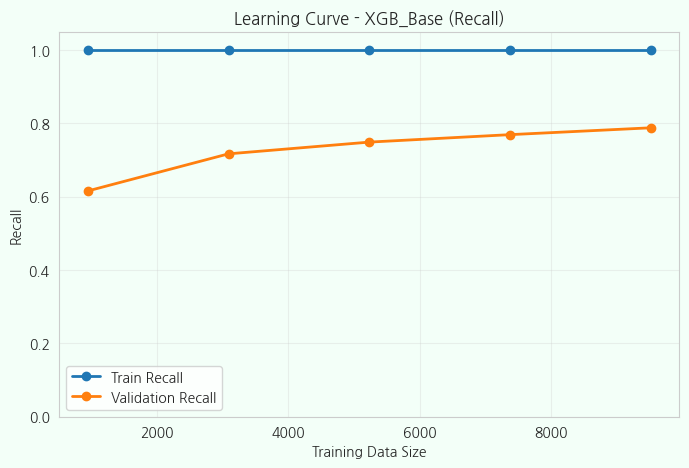

In [33]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=xgb_base,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8,5), facecolor='#F3FFF8')

ax = plt.gca()
ax.set_facecolor('#F3FFF8')

plt.plot(train_sizes, train_mean, marker='o', linewidth=2, label='Train Recall')
plt.plot(train_sizes, valid_mean, marker='o', linewidth=2, label='Validation Recall')

plt.title('Learning Curve - XGB_Base (Recall)')
plt.xlabel('Training Data Size')
plt.ylabel('Recall')
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [34]:
# XGBoost+SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb_smote = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    eval_metric='logloss',
    verbosity=0
)

xgb_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = xgb_smote.predict(X_test)
y_prob_sm = xgb_smote.predict_proba(X_test)[:, 1]
y_train_pred_sm = xgb_smote.predict(X_train)

print(f"\n[XGB_SMOTE]")
print(f"모델 정확도: {accuracy_score(y_test, y_pred_sm)*100:.2f}%")
print(classification_report(y_test, y_pred_sm, target_names=['정상(0)', '고장(1)']))

evaluate_model("XGB_SMOTE", y_test, y_pred_sm,y_prob_sm, y_train, y_train_pred_sm)


[XGB_SMOTE]
모델 정확도: 93.06%
              precision    recall  f1-score   support

       정상(0)       0.95      0.96      0.96      4069
       고장(1)       0.85      0.80      0.82      1031

    accuracy                           0.93      5100
   macro avg       0.90      0.88      0.89      5100
weighted avg       0.93      0.93      0.93      5100

XGB_SMOTE                      | TEST  | Acc=0.931 | P=0.845 | R=0.804 | F1=0.824 | ROC-AUC=0.961
XGB_SMOTE                      | TRAIN | Acc=0.997 | P=0.991 | R=0.995 | F1=0.993


In [35]:
# XGB+SMOTE+하이퍼파라미터 튜닝
xgb_smote_tuned = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,         # 트리 갯수. 더 많이 학습(100 -> 300)
    max_depth=4,              # 트리 깊이 제한. 과적합 방지  (6 -> 5)
    learning_rate=0.1,        # 학습률. 과적합 방지 (0.1 -> 0.05)
    subsample=0.8,            # 데이터 샘플 일부만 사용. 과적합 방지
    colsample_bytree=1,       # feature 일부만 사용. 과적합 방지
    eval_metric='logloss',
    verbosity=0
)

xgb_smote_tuned.fit(X_train_sm, y_train_sm)

y_pred_sm_t = xgb_smote_tuned.predict(X_test)
y_prob_sm_t = xgb_smote_tuned.predict_proba(X_test)[:, 1]
y_train_pred_sm_t = xgb_smote_tuned.predict(X_train)

print(f"\n[XGB_SMOTE_Tuned]")
print(f"모델 정확도: {accuracy_score(y_test, y_pred_sm_t)*100:.2f}%")
print(classification_report(y_test, y_pred_sm_t, target_names=['정상(0)', '고장(1)']))

evaluate_model("XGB_SMOTE_Tuned",y_test,y_pred_sm_t,y_prob_sm_t,y_train,y_train_pred_sm_t)


[XGB_SMOTE_Tuned]
모델 정확도: 91.12%
              precision    recall  f1-score   support

       정상(0)       0.95      0.94      0.94      4069
       고장(1)       0.76      0.81      0.79      1031

    accuracy                           0.91      5100
   macro avg       0.86      0.87      0.87      5100
weighted avg       0.91      0.91      0.91      5100

XGB_SMOTE_Tuned                | TEST  | Acc=0.911 | P=0.764 | R=0.811 | F1=0.787 | ROC-AUC=0.952
XGB_SMOTE_Tuned                | TRAIN | Acc=0.944 | P=0.834 | R=0.903 | F1=0.867


In [36]:
# XGBoost 하이퍼파라미터 튜닝
xgb_weight_tuned = xgb.XGBClassifier(
    random_state=42,          # 재현성 확보
    n_estimators=200,         # 트리 갯수. 더 많이 학습(100 -> 300)
    max_depth=4,              # 트리 깊이 제한. 과적합 방지  (6 -> 5)
    learning_rate=0.1,        # 학습률. 과적합 방지 (0.1 -> 0.05)
    subsample=0.8,            # 데이터 샘플 일부만 사용. 과적합 방지
    colsample_bytree=1,       # feature 일부만 사용. 과적합 방지
    scale_pos_weight=scale_w, # 클래스 불균형 보정.
    eval_metric='logloss',
    verbosity=0
)

xgb_weight_tuned.fit(X_train, y_train)

y_pred_w_t = xgb_weight_tuned.predict(X_test)
y_prob_w_t = xgb_weight_tuned.predict_proba(X_test)[:, 1]
y_train_pred_w_t = xgb_weight_tuned.predict(X_train)

print(f"\n[XGB_Weight_Tuned]")
print(f"모델 정확도: {accuracy_score(y_test, y_pred_w_t)*100:.2f}%")
print(classification_report(y_test, y_pred_w_t, target_names=['정상(0)', '고장(1)']))

evaluate_model("XGB_Weight_Tuned",y_test,y_pred_w_t,y_prob_w_t,y_train,y_train_pred_w_t)


[XGB_Weight_Tuned]
모델 정확도: 91.43%
              precision    recall  f1-score   support

       정상(0)       0.96      0.93      0.95      4069
       고장(1)       0.76      0.85      0.80      1031

    accuracy                           0.91      5100
   macro avg       0.86      0.89      0.87      5100
weighted avg       0.92      0.91      0.92      5100

XGB_Weight_Tuned               | TEST  | Acc=0.914 | P=0.756 | R=0.852 | F1=0.801 | ROC-AUC=0.957
XGB_Weight_Tuned               | TRAIN | Acc=0.949 | P=0.823 | R=0.953 | F1=0.883


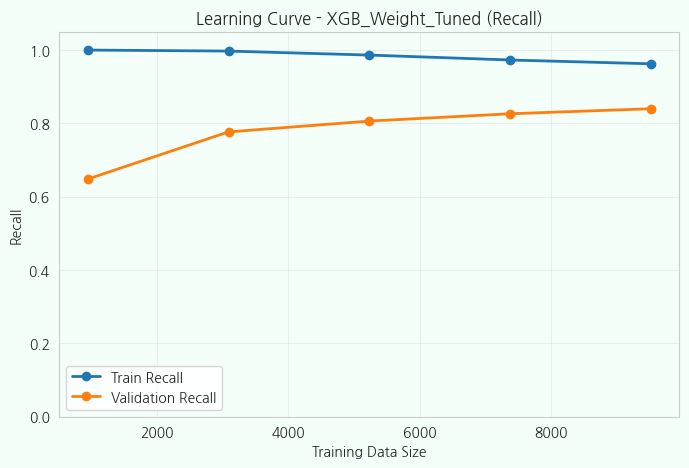

In [37]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=xgb_weight_tuned,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# 평균 계산
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

# 그래프
plt.figure(figsize=(8,5), facecolor='#F3FFF8')

ax = plt.gca()
ax.set_facecolor('#F3FFF8')

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label='Train Recall'
)

plt.plot(
    train_sizes,
    valid_mean,
    marker='o',
    linewidth=2,
    label='Validation Recall'
)

plt.title('Learning Curve - XGB_Weight_Tuned (Recall)')
plt.xlabel('Training Data Size')
plt.ylabel('Recall')

plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

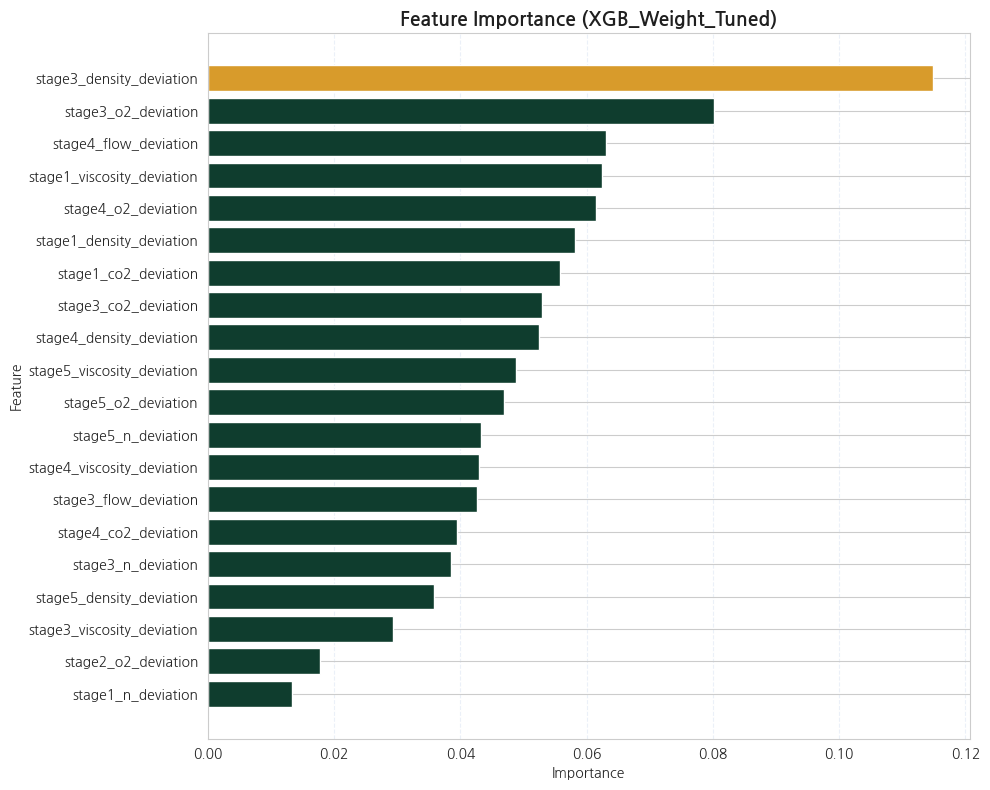

                       Feature  Importance
6     stage3_density_deviation    0.114934
9          stage3_o2_deviation    0.080228
11       stage4_flow_deviation    0.063061
1   stage1_viscosity_deviation    0.062468
15         stage4_o2_deviation    0.061544
0     stage1_density_deviation    0.058209
2         stage1_co2_deviation    0.055704
8         stage3_co2_deviation    0.052869
12    stage4_density_deviation    0.052506
17  stage5_viscosity_deviation    0.048814
18         stage5_o2_deviation    0.046957
19          stage5_n_deviation    0.043237
13  stage4_viscosity_deviation    0.042946
5        stage3_flow_deviation    0.042543
14        stage4_co2_deviation    0.039427
10          stage3_n_deviation    0.038541
16    stage5_density_deviation    0.035807
7   stage3_viscosity_deviation    0.029242
4          stage2_o2_deviation    0.017703
3           stage1_n_deviation    0.013260


In [38]:
importances = xgb_weight_tuned.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))

colors = ['#0f3d2e'] * len(fi_df)
colors[0] = '#d89b2b'  # 가장 중요한 변수 강조

plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)

plt.gca().invert_yaxis()

plt.title('Feature Importance (XGB_Weight_Tuned)', fontsize=14, fontweight='bold', color='#1F1F1F')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.5, color='#D9E2F3')

plt.tight_layout()
plt.show()

print(fi_df)

# 성능 비교

In [39]:
results_df = pd.DataFrame(model_eval_results)
# results_df = results_df.sort_values(by='F1-score', ascending=False)
# results_df = results_df.sort_values(by='Recall', ascending=False)
# results_df.reset_index(drop=True, inplace=True)

results_df
# results_df.style.highlight_max(color='green', axis=0)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic_Base,0.869608,0.785937,0.487876,0.602035,0.853506
1,Logistic_Scaled_Balanced,0.773529,0.464892,0.796314,0.587058,0.859805
2,Logistic_Scaled_SMOTE,0.774510,0.465785,0.785645,0.584838,0.859108
3,RF_Base,0.875686,0.950113,0.406402,0.569293,0.936501
4,RF_'Balanced',0.900196,0.766871,0.727449,0.746640,0.934980
5,RF_Threshold_0.32,0.798235,0.500521,0.931135,0.651068,0.934980
6,RF_SMOTE,0.884706,0.681706,0.806014,0.738667,0.935569
7,RF_SMOTETomek,0.892941,0.701915,0.817653,0.755376,0.936698
8,RF_ADASYN,0.861961,0.616040,0.841901,0.711475,0.936698
9,BalancedRF,0.889412,0.693776,0.810863,0.747764,0.938854


In [40]:
results_df_tr = pd.DataFrame(model_train_results)
# results_df_tr = results_df_tr.sort_values(by='F1-score', ascending=False)
# results_df_tr = results_df_tr.sort_values(by='Recall', ascending=False)
# results_df_tr.reset_index(drop=True, inplace=True)

results_df_tr.tail(4)

,Model,Accuracy,Precision,Recall,F1-score
10,XGB_Base,0.998739,0.994212,0.999584,0.996891
11,XGB_SMOTE,0.997058,0.990890,0.994597,0.992740
12,XGB_SMOTE_Tuned,0.944108,0.834165,0.903159,0.867292
13,XGB_Weight_Tuned,0.949067,0.823276,0.952618,0.883237


In [41]:
results_df = pd.DataFrame(model_eval_results)
results_df_tr = pd.DataFrame(model_train_results)

# Model 기준으로 merge
compare_df = pd.merge(results_df, results_df_tr, on='Model', suffixes=('_test', '_train'))

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    compare_df[f'{col}_diff'] = compare_df[f'{col}_train'] - compare_df[f'{col}_test']

compare_df = compare_df[[
    'Model',
    'Accuracy_test', 'Accuracy_train', 'Accuracy_diff',
    'Precision_test', 'Precision_train', 'Precision_diff',
    'Recall_test', 'Recall_train', 'Recall_diff',
    'F1-score_test', 'F1-score_train', 'F1-score_diff'
]]

compare_df.tail(4).style.background_gradient(
    subset=[col for col in compare_df.columns if 'diff' in col],
    cmap='Reds'
)

,Model,Accuracy_test,Accuracy_train,Accuracy_diff,Precision_test,Precision_train,Precision_diff,Recall_test,Recall_train,Recall_diff,F1-score_test,F1-score_train,F1-score_diff
10,XGB_Base,0.935098,0.998739,0.063641,0.857873,0.994212,0.136339,0.813773,0.999584,0.185811,0.835241,0.996891,0.161650
11,XGB_SMOTE,0.930588,0.997058,0.066470,0.845056,0.990890,0.145834,0.804074,0.994597,0.190523,0.824056,0.992740,0.168684
12,XGB_SMOTE_Tuned,0.911176,0.944108,0.032932,0.764168,0.834165,0.069997,0.810863,0.903159,0.092296,0.786824,0.867292,0.080468
13,XGB_Weight_Tuned,0.914314,0.949067,0.034753,0.755594,0.823276,0.067682,0.851600,0.952618,0.101018,0.800730,0.883237,0.082507


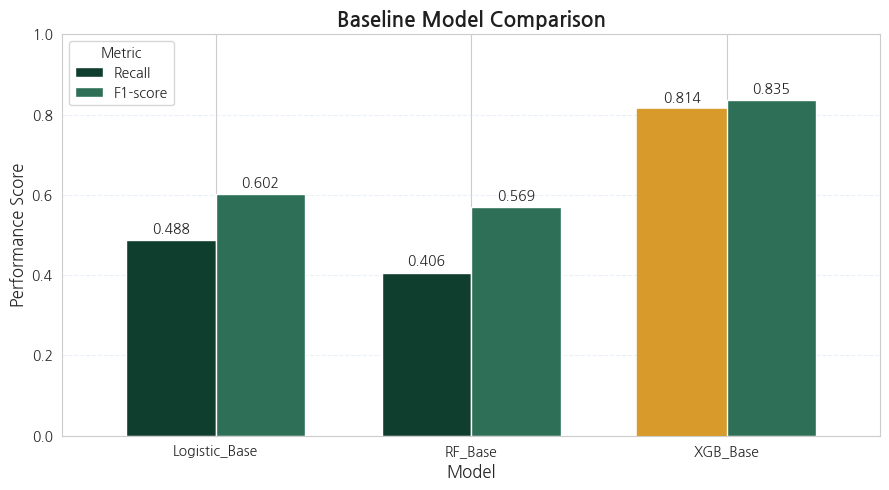

In [42]:
recall_color = '#0f3d2e'   # Recall 색상
f1_color = '#2e6f57'       # F1-score 색상
grid_color = '#D9E2F3'     # 그리드 색상
title_color = '#1F1F1F'    # 제목 색상

# '#0f3d2e': 딥그린 , '#2e6f57': 그린 , '#d89b2b': 골드

models_to_compare = ['Logistic_Base', 'RF_Base', 'XGB_Base']

df_plot = results_df[results_df['Model'].isin(models_to_compare)].copy()
df_plot = df_plot.set_index('Model')
metrics = ['Recall', 'F1-score']

# 강조
highlight_mode = 'manual'   # 'manual' / 'auto' / None
highlight_model = 'XGB_Base'     # 수동 강조 대상 (manual일 때만 사용)

ax = df_plot[metrics].plot(
    kind='bar',
    figsize=(9, 5),
    color=[recall_color, f1_color],
    width=0.7
)

bars = ax.containers  # [Recall bars, F1 bars]

if highlight_mode == 'manual':
    for i, bar in enumerate(bars[0]):  # Recall만
        if df_plot.index[i] == highlight_model:
            bar.set_color('#d89b2b')

elif highlight_mode == 'auto':
    max_idx = df_plot['Recall'].idxmax()
    for i, bar in enumerate(bars[0]):
        if df_plot.index[i] == max_idx:
            bar.set_color('#d89b2b')

plt.title(
    'Baseline Model Comparison',
    fontsize=15,
    fontweight='bold',
    color=title_color
)

plt.xlabel('Model', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.ylim(0, 1.0)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5, color=grid_color)

plt.legend(
    title='Metric',
    loc='upper left',
    frameon=True
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

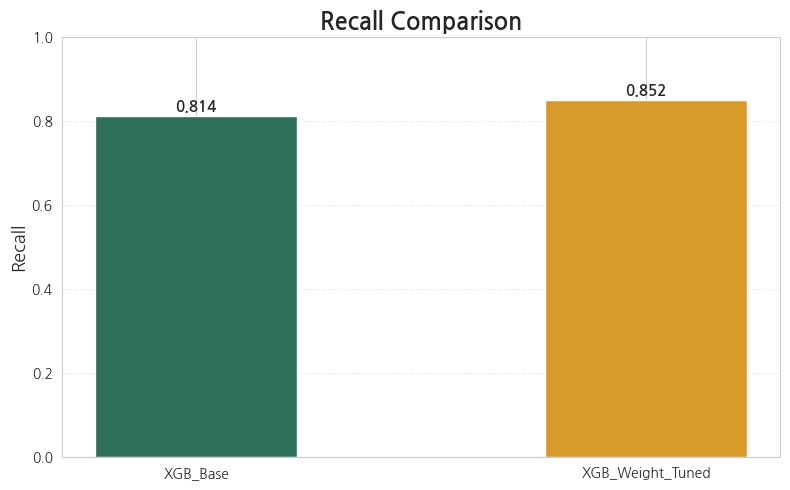

Recall 증가량: +0.038


In [43]:
def plot_recall_compare(
    results_df,
    model_list=['XGB_Base', 'XGB_Weight_Tuned'],
    high_color='#d89b2b',   # 반도체 느낌 노란색
    low_color='#2e6f57',    # 초록색
    title='Recall Comparison'
):

    # 비교 모델 선택
    plot_df = results_df[results_df['Model'].isin(model_list)].copy()

    # 모델 순서 고정
    plot_df['Model'] = pd.Categorical(
        plot_df['Model'],
        categories=model_list,
        ordered=True
    )

    plot_df = plot_df.sort_values('Model')

    # Recall 값 기준 색상 설정
    max_idx = plot_df['Recall'].idxmax()

    colors = []

    for idx in plot_df.index:
        if idx == max_idx:
            colors.append(high_color)
        else:
            colors.append(low_color)

    # 그래프 생성
    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        plot_df['Model'],
        plot_df['Recall'],
        color=colors,
        width=0.45   # 바 두께 줄임
    )

    # 값 표시
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    plt.title(title, fontsize=17, fontweight='bold')
    plt.ylabel('Recall', fontsize=13)

    plt.ylim(0, 1.0)

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

    # 증가량 따로 출력
    if len(plot_df) >= 2:

        recall_diff = (
            plot_df['Recall'].iloc[1]
            - plot_df['Recall'].iloc[0]
        )

        print(f"Recall 증가량: +{recall_diff:.3f}")

plot_recall_compare(results_df)

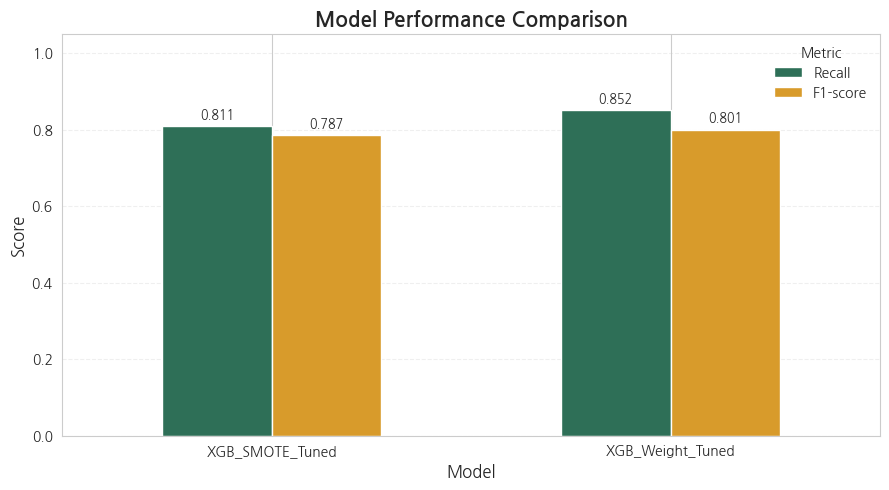

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_model_compare(
    results_df,
    model_list=['XGB_SMOTE_Tuned', 'XGB_Weight_Tuned'],
    colors=None,
    title="Model Performance Comparison"
):

    # 비교 모델 선택
    plot_df = results_df[results_df['Model'].isin(model_list)].copy()

    # 순서 고정
    plot_df['Model'] = pd.Categorical(
        plot_df['Model'],
        categories=model_list,
        ordered=True
    )

    plot_df = plot_df.sort_values('Model')

    # 사용할 지표
    metric_df = plot_df.set_index('Model')[['Recall', 'F1-score']]

    # 반도체 느낌 색상
    if colors is None:
        colors = ['#2e6f57', '#d89b2b']

    ax = metric_df.plot(
        kind='bar',
        figsize=(9, 5),
        color=colors,
        width=0.55
    )

    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Score", fontsize=12)

    plt.ylim(0, 1.05)

    plt.xticks(rotation=0)

    plt.legend(
        title="Metric",
        frameon=False
    )

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    # 값 표시
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            fontsize=9,
            padding=3
        )

    plt.tight_layout()
    plt.show()

plot_model_compare(results_df)

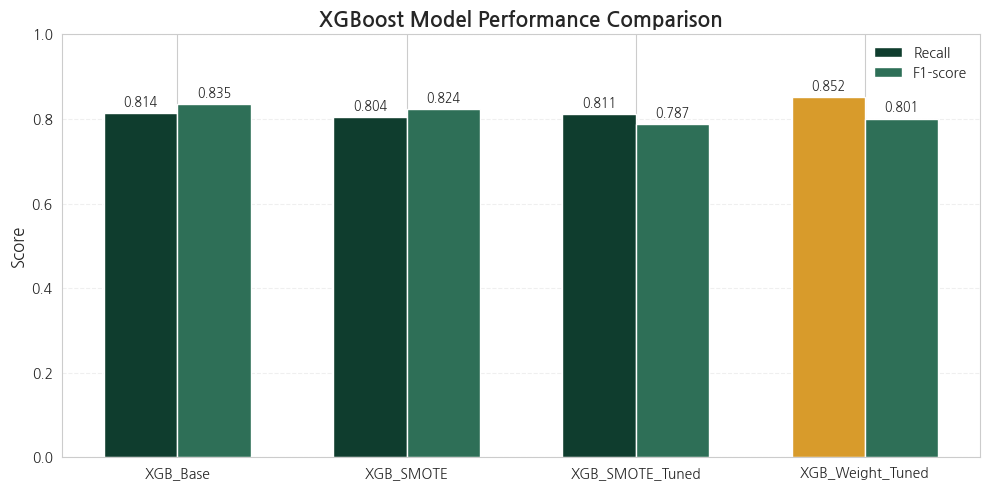

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_4model_compare(results_df):

    # 비교 모델
    model_list = [
        'XGB_Base',
        'XGB_SMOTE',
        'XGB_SMOTE_Tuned',
        'XGB_Weight_Tuned'
    ]

    # 데이터 선택
    plot_df = results_df[results_df['Model'].isin(model_list)].copy()

    # 순서 고정
    plot_df['Model'] = pd.Categorical(
        plot_df['Model'],
        categories=model_list,
        ordered=True
    )

    plot_df = plot_df.sort_values('Model')

    # 값 추출
    recalls = plot_df['Recall'].values
    f1s = plot_df['F1-score'].values

    x = np.arange(len(model_list))
    width = 0.32

    # 기본 색상
    recall_colors = ['#0f3d2e'] * len(model_list)   # 딥그린
    f1_colors = ['#2e6f57'] * len(model_list)       # 그린

    # Recall 최고값만 골드
    best_idx = np.argmax(recalls)
    recall_colors[best_idx] = '#d89b2b'

    # 그래프
    fig, ax = plt.subplots(figsize=(10, 5))

    bars1 = ax.bar(
        x - width/2,
        recalls,
        width,
        label='Recall',
        color=recall_colors
    )

    bars2 = ax.bar(
        x + width/2,
        f1s,
        width,
        label='F1-score',
        color=f1_colors
    )

    # 스타일
    ax.set_title(
        'XGBoost Model Performance Comparison',
        fontsize=15,
        fontweight='bold'
    )

    ax.set_ylabel('Score', fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(model_list)

    ax.set_ylim(0, 1.0)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.legend(frameon=False)

    # 값 표시
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()


plot_4model_compare(results_df)

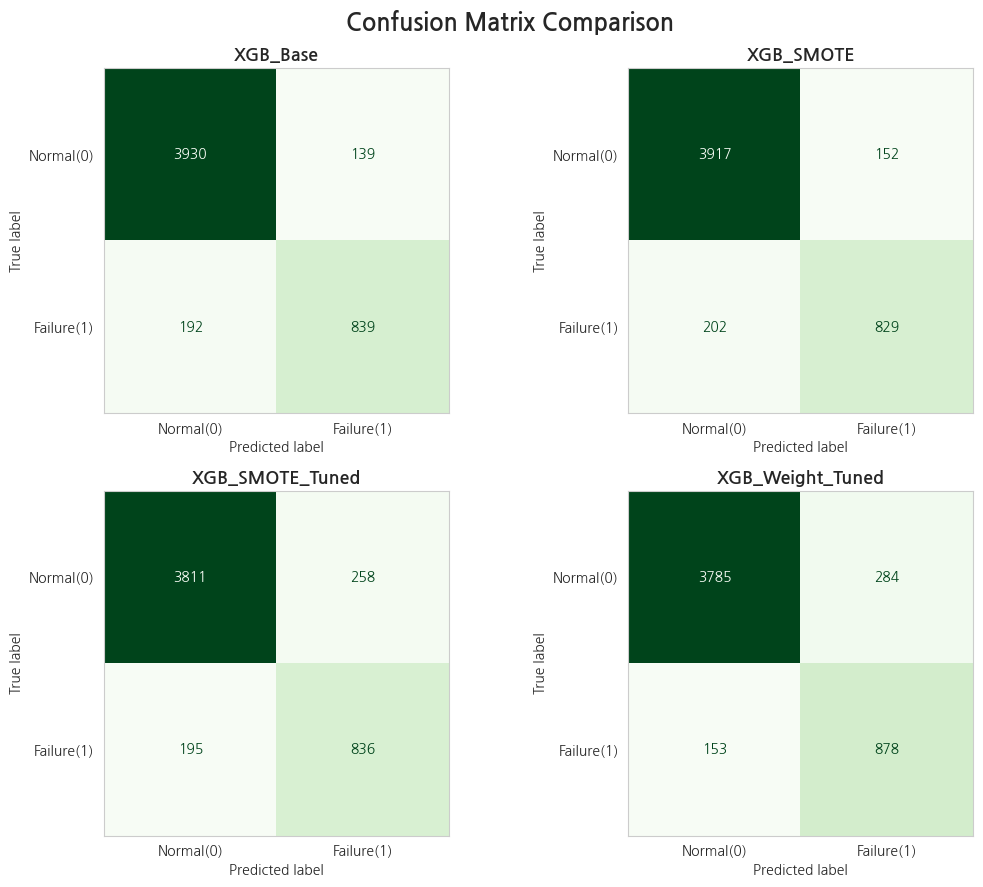

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_xgb_confusion_matrices(
    y_test,
    pred_dict
):
    """
    pred_dict 예시:
    {
        'XGB_Base': y_pred_xgb,
        'XGB_SMOTE': y_pred_smote,
        'XGB_SMOTE_Tuned': y_pred_smote_tuned,
        'XGB_Weight_Tuned': y_pred_weight
    }
    """

    model_names = list(pred_dict.keys())

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    axes = axes.flatten()

    for idx, model_name in enumerate(model_names):

        y_pred = pred_dict[model_name]

        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Normal(0)', 'Failure(1)']
        )

        disp.plot(
            ax=axes[idx],
            cmap='Greens',
            colorbar=False
        )

        axes[idx].set_title(
            model_name,
            fontsize=13,
            fontweight='bold'
        )

        axes[idx].grid(False)

    plt.suptitle(
        'Confusion Matrix Comparison',
        fontsize=17,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.show()

pred_dict = {
    'XGB_Base': y_pred_xgb,
    'XGB_SMOTE': y_pred_sm,
    'XGB_SMOTE_Tuned': y_pred_sm_t,
    'XGB_Weight_Tuned': y_pred_w_t
}

plot_xgb_confusion_matrices(y_test, pred_dict)

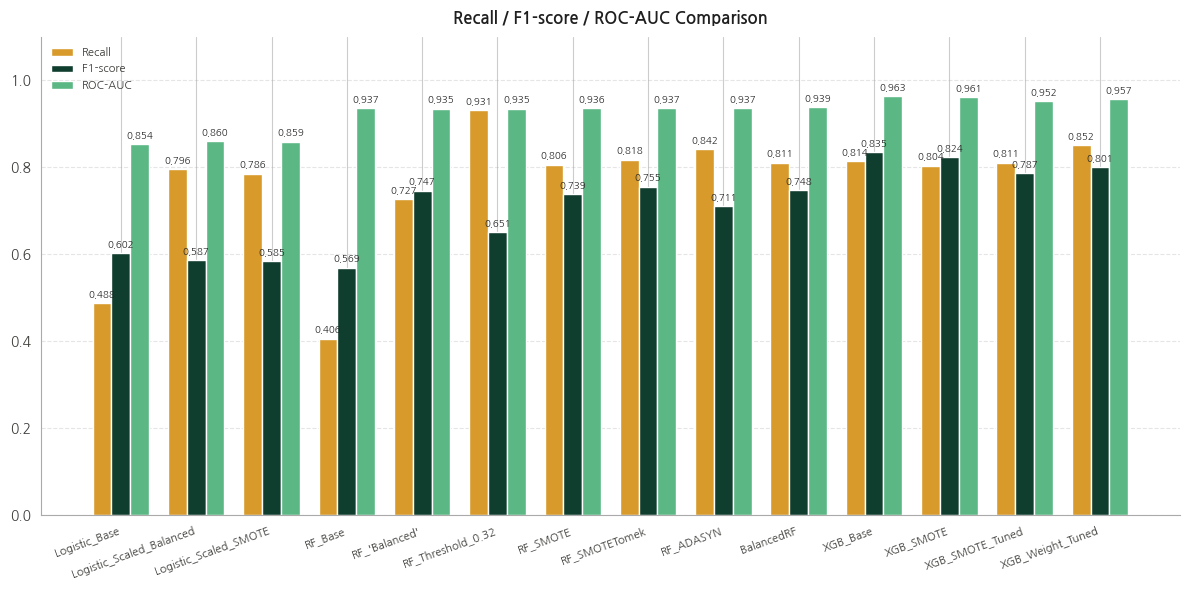

In [50]:
def plot_combined(ax):
    x = np.arange(len(results_df))
    width = 0.25

    bars1 = ax.bar(x - width, results_df['Recall'],   width, label='Recall',   color='#d89b2b')  # 골드
    bars2 = ax.bar(x,         results_df['F1-score'], width, label='F1-score', color='#0f3d2e')  # 딥그린
    bars3 = ax.bar(x + width, results_df['ROC-AUC'],  width, label='ROC-AUC',  color='#5bb885')  # 연한 녹색

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_title('Recall / F1-score / ROC-AUC Comparison', fontsize=12,
             fontweight='bold', color='#1F1F1F', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_edgecolor('#aaa')
    ax.tick_params(colors='#3d3d3a')
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#aaa')
    ax.legend(frameon=False, fontsize=8, labelcolor='#3d3d3a')

fig, ax = plt.subplots(figsize=(12, 6))
plot_combined(ax)
plt.tight_layout()
plt.savefig('combined_bar.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()